## Database and SQL for Data Analytics with Python

> In this notebook we will build a data pipeline from raw source to an SQL database, establishing a SQLite database connection via Python API, loading the raw data, and executing SQL queries. Core analysis queries are stored in dedicated SQL files while some queries are demonstrated inline within this notebook below.

In [1]:
#import all the essential libraries and modules
#installing the sql and plot related libraires in the local notebook, since this is a new environemnt.
!pip install ipython-sql prettytable 
import pandas as pd
import sqlite3
import csv
import prettytable

prettytable.DEFAULT = 'DEFAULT'


### Step 1: Connect to the Database 

(self note: Connection methods of all the three types we learned namely cursor, pandas, and %sql must be written here)

In [2]:
connection = sqlite3.connect('sales.db') #connection established with an API call 'connect'
#load sql magic module 
%load_ext sql 
%sql sqlite:///sales.db #magic module connected to the 'sales database'

(sqlite3.OperationalError) near "#magic": syntax error
[SQL: #magic module connected to the 'sales database']
(Background on this error at: https://sqlalche.me/e/20/e3q8)


In [3]:
#optional cell
from sqlalchemy import create_engine 
engine = create_engine('sqlite:///sales.db')

### STEP 2: Read the datasets and convert them into databse tables by creating new tables

In [4]:
df = pd.read_csv(r"C:\Users\DELL\Documents\data-analytics-sql\datasets\superstore.csv")
print (df.shape)
df['sales'] = pd.to_numeric(df['sales'], errors='coerce') #there is an error with the sales column which is making it appear as a string value. W eneed to change that
df.head()

(51290, 21)


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011


### Step 3: Create a simple DATABASE table out of the original dataset/flat csv file
> We will create one raw table with all the sheet data as it is which we can query later with %sql directly in the notebook.

Then we will create three DIMENSIONAL tables out of the single spreadsheet so to be able to organize the entire data queries more effectively. These three tables will be connected with their Primary keys to the facts table with Foreign keys

Effectively this will internally make a table schema which will be more organised and which we can retrieve and display in our repo 

In [5]:
# option 1: 
original_table = df.to_sql('superstore_original', connection, if_exists = 'replace', index = False) 
original_table

51290

In [6]:
#2 Option:2
original_table = df.to_sql ('superstore_original', engine, if_exists = 'replace', index = False) 
original_table

51290

In [7]:
%%sql 
SELECT * FROM superstore_original LIMIT 2;

 * sqlite:///sales.db
Done.


order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408.0,2,0.0,106.14,35.46,Medium,2011
IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011


### Step 4: Create the dimension tables and the facts table (star schema) one by one out of the large dataset in Pandas dataframe

- Three dimensional tables out of the flat spreadsheet. First, we wil create each dimenional table in pandas dataframe and then load them into sql databse tables/

#### 1. dim_customers table


In [8]:
dim_customers = df[['customer_name', 'segment']].drop_duplicates().reset_index(drop = True)
print (dim_customers.shape)
dim_customers.head(5)

(795, 2)


,customer_name,segment
0,Toby Braunhardt,Consumer
1,Joseph Holt,Consumer
2,Annie Thurman,Consumer
3,Eugene Moren,Home Office
4,Magdelene Morse,Consumer


#### Concept of subset in drop_duplicates(): Precautionary Cleaning step

In a messy real-world CSV data, the same product_id can sometimes appear with slightly different product_name spellings due to typos etc. 

- If we do drop_duplicates() on all 4 columns, it would not drop those slightly different misspelled names, considering them unique while they are just the same products_name misspelled (but their ids remain the same as the correctly spalled one). 

- So if we drop the duplicates based on whose id is repeating, not their name or any other repetitive measure, we can ensure all duplicates are really dropped

> subset='product_id' ensures that the deduplication is done only based on the product_id alone.

HENCE here we have to insert a subset='product_id' in the drop_duplicates paranthesis




#### 2. dim_products table

In [9]:
dim_products = df[['product_id', 'product_name', 'category', 'sub_category']].drop_duplicates(subset='product_id').reset_index(drop = True)   ## subset='product_id' because the same product_id can appear with # slightly different name spellings in raw data — id is the true unique key
print (dim_products.shape)
dim_products.head(5)

(10292, 4)


,product_id,product_name,category,sub_category
0,OFF-TEN-10000025,"Tenex Lockers, Blue",Office Supplies,Storage
1,OFF-SU-10000618,"Acme Trimmer, High Speed",Office Supplies,Supplies
2,OFF-TEN-10001585,"Tenex Box, Single Width",Office Supplies,Storage
3,OFF-PA-10001492,"Enermax Note Cards, Premium",Office Supplies,Paper
4,FUR-FU-10003447,"Eldon Light Bulb, Duo Pack",Furniture,Furnishings


#### dim_locations table: Concept of Creating a primary key

In the source data we can see that location-related attributes have NO natural unique key in the source data

> i) First, we deduplicate the entire table. Since there are no unique keys, we cannot use the precautionary subset in drop_duplicates. It is not super-essential.

> ii) Now that each row is unique, we can generate a surrogate key made of sequential integers 1, 2, 3.

This is to create a unique key which does not exist in original table so as to have a primary key in the dim_locations table which can then be used later to relate to/Join with other tables like 'facts_orders' of the star schema.

Note: len(dim_locations) = number of rows, not string length

#### 3. dim_locations table


In [10]:
dim_locations = df[['state', 'country', 'market', 'region']].drop_duplicates().reset_index(drop=True) #i)
dim_locations.insert(0, 'location_id', range(1, len(dim_locations) + 1)) #ii)

#V.important: Since the dataframe is updated, we need to use the new dataframe fro fact_orders table. For that we need to update the existing dataframe withou touching the original dataframe as that is a reference.
df_updated = df.merge(dim_locations, on=['state', 'country', 'market', 'region'], how='left') #updated dataframe

print (dim_locations.shape)
dim_locations.head()

(1126, 5)


,location_id,state,country,market,region
0,1,Constantine,Algeria,Africa,Africa
1,2,New South Wales,Australia,APAC,Oceania
2,3,Budapest,Hungary,EMEA,EMEA
3,4,Stockholm,Sweden,EU,North
4,5,Ontario,Canada,Canada,Canada


#### 4. fact_orders table: 
The table containing all the measurable numbers as well as foreign keys from other three dimesion tables. 

In [11]:
fact_orders = df_updated[['order_id', 'order_date', 'ship_date', 'ship_mode',   #using the uopdated dataframe with the location_id as we need the location_id column as a froeign key
                            'sales', 'quantity', 'discount', 'profit',
                            'shipping_cost', 'order_priority', 'year',
                            'customer_name', 'product_id', 'location_id']]

# dimension tables store descriptive attributes — duplicates mean dirty data
# fact_orders stores transactions — every row IS a unique event
# dropping duplicates here would mean deleting real sales records

print(fact_orders.shape)
fact_orders.head()

(51290, 14)


,order_id,order_date,ship_date,ship_mode,sales,quantity,discount,profit,shipping_cost,order_priority,year,customer_name,product_id,location_id
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,408.0,2,0.0,106.140,35.46,Medium,2011,Toby Braunhardt,OFF-TEN-10000025,1
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,120.0,3,0.1,36.036,9.72,Medium,2011,Joseph Holt,OFF-SU-10000618,2
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,66.0,4,0.0,29.640,8.17,High,2011,Annie Thurman,OFF-TEN-10001585,3
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,45.0,3,0.5,-26.055,4.82,High,2011,Eugene Moren,OFF-PA-10001492,4
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,114.0,5,0.1,37.770,4.70,Medium,2011,Joseph Holt,FUR-FU-10003447,2


In [ ]:
#datetime in the original datset is stored in a string variable as '1/1/2011'. to be recognised by strftime we need to convert it to datetime object'Y-m-d' format
fact_orders['order_date'] = pd.to_datetime(fact_orders['order_date'], dayfirst=True).dt.strftime('%Y-%m-%d')
fact_orders['ship_date'] = pd.to_datetime(fact_orders['ship_date'], dayfirst=True).dt.strftime('%Y-%m-%d')

### Step 5: Loading the dimensional sub-tables into our sales.db database, to be able to execute SQL queries

In [13]:
dim_locations.to_sql('dim_locations', connection, if_exists='replace', index=False)
dim_customers.to_sql('dim_customers', connection, if_exists='replace', index=False)
dim_products.to_sql('dim_products', connection, if_exists='replace', index=False)
fact_orders.to_sql('fact_orders', connection, if_exists = 'replace', index=False)
print('dimension tables loaded')

dimension tables loaded


## Validation: verify if all the 'star schema' dimensional tables are successfully loaded in the DB: 

In [14]:
%%sql
SELECT
    (SELECT COUNT(*) FROM fact_orders)   AS total_orders,
    (SELECT COUNT(*) FROM dim_customers) AS total_customers,
    (SELECT COUNT(*) FROM dim_products)  AS total_products,
    (SELECT COUNT(*) FROM dim_locations) AS total_locations


 * sqlite:///sales.db
Done.


total_orders,total_customers,total_products,total_locations
51290,795,10292,1126


## Table Schema

In [15]:
%%sql
SELECT * FROM sqlite_master;

 * sqlite:///sales.db
Done.


type,name,tbl_name,rootpage,sql
view,report_customers,report_customers,0,"CREATE VIEW report_customers ASWITH customer_summary AS ( SELECT c.customer_name, c.segment, COUNT(DISTINCT f.order_id) AS total_orders, ROUND(SUM(f.sales), 2) AS total_revenue, ROUND(SUM(f.profit), 2) AS total_profit, ROUND(SUM(f.profit) / SUM(f.sales) * 100, 2) AS profit_margin_pct, MIN(f.order_date) AS first_order, MAX(f.order_date) AS last_order FROM fact_orders f JOIN dim_customers c ON f.customer_name = c.customer_name GROUP BY c.customer_name, c.segment)SELECT customer_name, segment, total_orders, total_revenue, total_profit, profit_margin_pct, first_order, last_order, CASE WHEN total_revenue > 10000 THEN 'VIP' WHEN total_revenue > 5000 THEN 'Loyal' WHEN total_revenue > 1000 THEN 'Regular' ELSE 'Occasional' END AS customer_segmentFROM customer_summaryORDER BY total_revenue DESC"
view,report_products,report_products,0,"CREATE VIEW report_products ASWITH product_summary AS ( SELECT p.product_name, p.category, p.sub_category, COUNT(DISTINCT f.order_id) AS total_orders, ROUND(SUM(f.sales), 2) AS total_revenue, ROUND(SUM(f.profit), 2) AS total_profit, ROUND(SUM(f.profit) / SUM(f.sales) * 100, 2) AS profit_margin_pct, MIN(f.order_date) AS first_order, MAX(f.order_date) AS last_order FROM fact_orders f JOIN dim_products p ON f.product_id = p.product_id GROUP BY p.product_name, p.category)SELECT product_name, category, sub_category, total_orders, total_revenue, total_profit, profit_margin_pct, first_order, last_order, CASE WHEN total_profit > 10000 THEN 'High Performer' WHEN total_profit > 5000 THEN 'Mid Performer' WHEN total_profit > 1000 THEN 'Low performer' ELSE 'Losing Money' END AS product_segmentFROM product_summaryORDER BY total_profit DESC"
table,superstore_original,superstore_original,2,"CREATE TABLE superstore_original ( order_id TEXT, order_date TEXT, ship_date TEXT, ship_mode TEXT, customer_name TEXT, segment TEXT, state TEXT, country TEXT, market TEXT, region TEXT, product_id TEXT, category TEXT, sub_category TEXT, product_name TEXT, sales FLOAT, quantity BIGINT, discount FLOAT, profit FLOAT, shipping_cost FLOAT, order_priority TEXT, year BIGINT)"
table,dim_locations,dim_locations,3,"CREATE TABLE ""dim_locations"" (""location_id"" INTEGER, ""state"" TEXT, ""country"" TEXT, ""market"" TEXT, ""region"" TEXT)"
table,dim_customers,dim_customers,2847,"CREATE TABLE ""dim_customers"" (""customer_name"" TEXT, ""segment"" TEXT)"
table,dim_products,dim_products,2849,"CREATE TABLE ""dim_products"" (""product_id"" TEXT, ""product_name"" TEXT, ""category"" TEXT, ""sub_category"" TEXT)"
table,fact_orders,fact_orders,3071,"CREATE TABLE ""fact_orders"" (""order_id"" TEXT, ""order_date"" TEXT, ""ship_date"" TEXT, ""ship_mode"" TEXT, ""sales"" REAL, ""quantity"" INTEGER, ""discount"" REAL, ""profit"" REAL, ""shipping_cost"" REAL, ""order_priority"" TEXT, ""year"" INTEGER, ""customer_name"" TEXT, ""product_id"" TEXT, ""location_id"" INTEGER)"


- The user is encouraged to look into the relevant table schema and structure explaining how the original data was split into dimenstional tables for better querying. The relevant Schema and Create Statments are saved with the following command in a .sql file and stored in the 'scripts' folder of the github repository.

In [16]:
schema = pd.read_sql("SELECT name, sql FROM sqlite_master WHERE type='table'", connection)

# Save to scripts folder (one level up, into scripts/ as cleanly separated columns)
with open('../scripts/table_schema_documentation.txt', 'w') as f:
    for _, row in schema.iterrows():
        f.write(f"Table: {row['name']}\n")
        f.write(f"{row['sql']}\n")
        f.write("\n" + "="*50 + "\n\n")
#schema saved!

## SQL Demo
#### A short demonstration of some of the SQL queries (from 02_exploratory_analysis.sql) using Python's magic %sql command

In [17]:
%%sql
SELECT * FROM fact_orders LIMIT 5;

 * sqlite:///sales.db
Done.


order_id,order_date,ship_date,ship_mode,sales,quantity,discount,profit,shipping_cost,order_priority,year,customer_name,product_id,location_id
AG-2011-2040,2011-01-01,2011-01-06,Standard Class,408.0,2,0.0,106.14,35.46,Medium,2011,Toby Braunhardt,OFF-TEN-10000025,1
IN-2011-47883,2011-01-01,2011-01-08,Standard Class,120.0,3,0.1,36.036,9.72,Medium,2011,Joseph Holt,OFF-SU-10000618,2
HU-2011-1220,2011-01-01,2011-01-05,Second Class,66.0,4,0.0,29.64,8.17,High,2011,Annie Thurman,OFF-TEN-10001585,3
IT-2011-3647632,2011-01-01,2011-01-05,Second Class,45.0,3,0.5,-26.055,4.82,High,2011,Eugene Moren,OFF-PA-10001492,4
IN-2011-47883,2011-01-01,2011-01-08,Standard Class,114.0,5,0.1,37.77,4.7,Medium,2011,Joseph Holt,FUR-FU-10003447,2


### Q: What is the DATE RANGE of the sales data?
SKILLS:   SELECT, MIN, MAX, aggregate functions

In [18]:
%%sql 

SELECT 

MIN(order_date) AS FIRST_ORDER, 
MAX (order_date) AS LAST_ORDER, 
COUNT(DISTINCT (year)) AS YEARS_PASSED 

from fact_orders;

 * sqlite:///sales.db
Done.


FIRST_ORDER,LAST_ORDER,YEARS_PASSED
2011-01-01,2014-12-31,4


Insights: Our time-based analysis goes between January 2011 and Septemebr 2014 (not December 2014)

### Q: What is the overall scale of the business?
SKILLS: COUNT DISTINCT, SUM, ROUND, aggregate functions

> Note: Profit Margin is the fraction of profit generated over revenue generated. \
    > profit margin percentage =  (profit/sales) * 100

> order_id is a primary key and unique. As for customer name and product_id, we are interested in the types of all the products sold and the count of all the individual customers buying from the business.   

In [19]:
%%sql

SELECT 
COUNT (order_id) AS total_orders_placed, 
COUNT (DISTINCT(customer_name)) AS total_customers,
COUNT (DISTINCT(product_id)) AS total_products_sold,

ROUND (SUM (sales), 2) AS generated_revenue,
ROUND (SUM(profit), 2) AS "total_profit",
ROUND((SUM(profit)/SUM (sales))*100, 2) AS "%_profit_margin"

FROM fact_orders;


 * sqlite:///sales.db
Done.


total_orders_placed,total_customers,total_products_sold,generated_revenue,total_profit,%_profit_margin
51290,795,10292,7835128.0,1469034.82,18.75


### Q. Which REGIONS generate the most revenue and profit?
SKILLS:   GROUP BY, ORDER BY, SUM, ROUND, JOIN
> For a better picture, we will print out the profit_margin as well to better formulate the business story

In [20]:
%%sql 

SELECT 
    l.region AS Region, 
    ROUND(SUM(f.sales), 2) AS generated_revenue,
    ROUND(SUM(f.profit), 2) AS total_profit,
    ROUND((SUM(f.profit)/SUM(f.sales) *100), 2) AS profit_margin_percentage

FROM fact_orders f

JOIN dim_locations l ON f.location_id = l.location_id
GROUP BY Region
ORDER BY total_profit desc;

 * sqlite:///sales.db
Done.


Region,generated_revenue,total_profit,profit_margin_percentage
Central,1806638.0,311403.98,17.24
North,790546.0,194597.95,24.62
North Asia,453686.0,165578.42,36.5
South,1031101.0,140355.77,13.61
Central Asia,389506.0,132480.19,34.01
Oceania,625382.0,121666.64,19.45
West,424173.0,108418.45,25.56
East,366492.0,91522.78,24.97
Africa,538115.0,88871.63,16.52
EMEA,575562.0,43897.97,7.63


Insights: 

- 'Central' region dominates in both revenue AND profit - leading region.

- North has only $790 k revenue but $194 k profit — a 24.6% profit margin, very efficient

- Southeast Asia has $532 k revenue but only $17 k profit — with a  lowest 3.3% profit margin, reaching an almost "breaking even" stage.

- EMEA similarly has low profitability despite a higher revenue a $575 k revenue but only $43 k profit 

### Q: Which PRODUCTS categories are most and least profitable?
SKILLS:   GROUP BY, JOIN, SUM, ROUND, ORDER BY

In [21]:
%%sql 
SELECT 
    p.category AS product_category,
    ROUND(SUM(f.profit), 2) AS total_profit,
    ROUND(SUM(f.sales), 2) AS total_revenue,
    ROUND((SUM(f.profit)/SUM(f.sales)*100), 2) AS "profit_margin_%"

FROM dim_products p

JOIN fact_orders f ON p.product_id = f.product_id
GROUP BY product_category
ORDER BY total_profit desc;

 * sqlite:///sales.db
Done.


product_category,total_profit,total_revenue,profit_margin_%
Technology,663778.73,2638265.0,25.16
Office Supplies,518473.83,2790258.0,18.58
Furniture,286782.25,2406605.0,11.92


Insights: 
- Furniture generates the second highest revenue but has the worst profit margin by far. 

--------------------------------------

003_time_series_analysis

Caution: In the original datset, datetime is stored in a string variable as '1/1/2011'. \
strftime could only recognise it if it is in a proper datetime format 'Y-m-d'. we needed to convert it to datetime object'Y-m-d' format.\

tip for future: always make sure the datetime column has a proper datetime format and not a string format.


QUESTION: How did metrics, revenue, and profit trend year over year?\
SKILLS:   DATE functions, GROUP BY, ORDER BY, SUM \
WHERE order_date IS NOT NULL #IMPORTANT


In [22]:
%%sql 

SELECT 
    COUNT(DISTINCT(order_id)) AS number_of_orders,

    ROUND(SUM(sales), 2) AS total_annual_revenue,
    ROUND(SUM(profit), 2) AS total_annual_profit,
    ROUND((SUM(profit)/SUM(sales)*100), 2) AS "profit_margin_%",

    STRFTIME('%Y', order_date) AS order_year

from fact_orders
WHERE order_date IS NOT NULL
GROUP BY order_year
ORDER BY order_year asc;


 * sqlite:///sales.db
Done.


number_of_orders,total_annual_revenue,total_annual_profit,profit_margin_%,order_year
4440,1378151.0,248940.81,18.06,2011
5343,1681499.0,307415.28,18.28,2012
6721,2107021.0,408512.76,19.39,2013
8531,2668457.0,504165.97,18.89,2014


QUESTION: Which months consistently generate the most revenue\
SKILLS:   DATE functions, GROUP BY, ORDER BY, SUM

> Note: WHERE order_date IS NOT NULL #IMPORTANT

In [23]:
%%sql

SELECT 

    ROUND(SUM(sales), 2) AS total_monthly_revenue,
    ROUND(SUM(profit), 2) AS total_monthly_profit,

    STRFTIME('%m', order_date) AS order_month

from fact_orders

WHERE order_date IS NOT NULL

GROUP BY order_month
order by total_monthly_revenue desc;

 * sqlite:///sales.db
Done.


total_monthly_revenue,total_monthly_profit,order_month
988420.0,175449.48,11
957117.0,170718.13,12
893366.0,170438.18,09
807184.0,147079.42,06
784982.0,151854.11,08
705696.0,157269.36,10
562178.0,104509.78,05
488345.0,78070.09,07
466475.0,94087.52,03
455594.0,73513.63,04


INSIGHT: Nov, Dec dominate the revenue generation as holiday months.\
Feb and Jan are weakest — typical post-holiday retail slowdown.

QUESTION: How does revenue trend across each month of each year? \
SKILLS:   DATE functions, GROUP BY multiple columns, ORDER BY \

> Important Note: Order by and Group by do not take logical operators such as AND/OR. For multiple columns to sort by simply separate them by a comma in both GROUP BY AND ORDER BY 



In [24]:
%%sql 

SELECT  

    COUNT (DISTINCT(order_id)) AS number_of_orders,
    ROUND(SUM(sales), 2) AS total_revenue,
    ROUND(SUM(profit), 2) AS total_profit,

strftime('%m', order_date) AS month_of_order,
strftime('%Y', order_date) AS year_of_order

from fact_orders

WHERE month_of_order AND year_of_order IS NOT NULL
GROUP BY month_of_order, year_of_order
ORDER BY year_of_order ASC, month_of_order ASC;

 * sqlite:///sales.db
Done.


number_of_orders,total_revenue,total_profit,month_of_order,year_of_order
216,64363.0,8321.8,01,2011
183,60848.0,12417.91,02,2011
277,78983.0,15303.57,03,2011
267,80698.0,12902.32,04,2011
295,91536.0,12183.83,05,2011
468,142526.0,23415.25,06,2011
250,75412.0,5585.0,07,2011
443,132065.0,23713.67,08,2011
527,153992.0,35776.88,09,2011
401,122853.0,25963.42,10,2011


Insights: 
- November/December spike repeats every year consistently with the difference between seasons measuring up to twice its size.
- Year on year growth visible within same months across years.

--------------------------------------------------------------------------------------------------------------------------------

QUESTION: How does cumulative revenue grow month by month?\
SKILLS:   Window functions, SUM() OVER(), ORDER BY, DATE functions\


Note: 'year always come before monthin the order of grouping' otherwise all the januaries of all the years will be sorted first etc

In [ ]:
%%sql

SELECT 

ROUND(SUM (sales), 2) AS total_monthly_revenue, 

STRFTIME('%m', order_date) AS month_of_order,
STRFTIME('%Y', order_date) AS year_of_order,

ROUND(SUM(SUM(sales)) OVER 
                        (ORDER BY STRFTIME('%Y', order_date), 
                        STRFTIME('%m', order_date)), 2) 
                        AS running_total

from fact_orders
WHERE order_date IS NOT NULL
GROUP BY year_of_order, month_of_order 
ORDER BY year_of_order, month_of_order; 

In [ ]:
%%sql

SELECT 
    STRFTIME('%Y', order_date) AS order_year,
    STRFTIME('%m', order_date) AS order_month,

    ROUND(SUM(sales), 2) AS total_monthly_revenue,

    ROUND(SUM(SUM(sales)) OVER 
                            (PARTITION BY STRFTIME('%Y', order_date)
                            ORDER BY STRFTIME('%m', order_date) ) , 2) AS running_total_per_year
    
from fact_orders
WHERE order_date IS NOT NULL
GROUP BY order_year, order_month

ORDER BY order_year, order_month;    

---------------------------------------------------------------------------------------------------------------------------------

QUESTION: Which products are high, mid or low performers based on total profit generated?\
SKILLS:   CASE WHEN, GROUP BY, JOIN, SUM, ORDER BY

In [ ]:
%%sql 

SELECT
    p.product_name,
    p.category,
    ROUND(SUM(f.profit), 2) AS total_profit,
    CASE
        WHEN SUM(f.profit) > 5000  THEN 'High Performer'
        WHEN SUM(f.profit) > 1000  THEN 'Mid Performer'
        WHEN SUM(f.profit) > 0     THEN 'Low Performer'
        ELSE 'Losing Money'
    END AS performance_segment
FROM fact_orders f
JOIN dim_products p ON f.product_id = p.product_id
GROUP BY p.product_name, p.category
ORDER BY total_profit DESC;

In [28]:
%%sql 

SELECT
    performance_segment,
    COUNT(*) AS number_of_products
FROM (
    SELECT
        p.product_name,
        ROUND(SUM(f.profit), 2) AS total_profit,
        CASE
            WHEN SUM(f.profit) > 5000 THEN 'High Performer'
            WHEN SUM(f.profit) > 1000 THEN 'Mid Performer'
            WHEN SUM(f.profit) > 0    THEN 'Low Performer'
            ELSE 'Losing Money'
        END AS performance_segment
    FROM fact_orders f
    JOIN dim_products p ON f.product_id = p.product_id
    GROUP BY p.product_name
) AS product_segments
GROUP BY performance_segment
ORDER BY number_of_products DESC;


 * sqlite:///sales.db
Done.


performance_segment,number_of_products
Low Performer,2564
Losing Money,674
Mid Performer,405
High Performer,41


QUESTION: Which customers are VIP, Loyal, Regular or Occasional based on total revenue generated? \
SKILLS:   CASE WHEN, GROUP BY, JOIN, SUM, ORDER BY

In [29]:
%%sql

SELECT
    c.customer_name,
    ROUND(SUM(f.sales), 2) AS total_revenue,
        CASE
            WHEN SUM(f.sales) > 10000 THEN 'VIP'
            WHEN SUM(f.sales) > 5000 THEN 'Loyal'
            WHEN SUM(f.sales) > 1000 THEN 'Regular'
            ELSE 'Occasional'
    END AS performance_segment
FROM fact_orders f
JOIN dim_customers c ON f.customer_name = c.customer_name
GROUP BY c.customer_name
ORDER BY total_revenue DESC LIMIT 5;

 * sqlite:///sales.db
Done.


customer_name,total_revenue,performance_segment
Eric Murdock,19489.0,VIP
John Grady,19483.0,VIP
Maria Etezadi,18237.0,VIP
Theone Pippenger,17416.0,VIP
Dan Reichenbach,16705.0,VIP


In [30]:
%%sql 

SELECT
    performance_segment,
    COUNT(*) AS number_of_customers
FROM (
    SELECT
        c.customer_name,
        ROUND(SUM(f.sales), 2) AS total_revenue,
            CASE
                WHEN SUM(f.sales) > 10000 THEN 'VIP'
                WHEN SUM(f.sales) > 5000 THEN 'Loyal'
                WHEN SUM(f.sales) > 1000 THEN 'Regular'
                ELSE 'Occasional'
        END AS performance_segment
    FROM fact_orders f
    JOIN dim_customers c ON f.customer_name = c.customer_name
    GROUP BY c.customer_name
) AS customer_segments
GROUP BY performance_segment
ORDER BY number_of_customers DESC;

 * sqlite:///sales.db
Done.


performance_segment,number_of_customers
Loyal,399
VIP,373
Regular,23


Advanced Analytics
----------------------------------------------------------------------------------------------------------------------------------------

QUESTION: How did profit grow year over year — and by how much? \
SKILLS:   LAG(), window functions, CTE, date functions, ROUND

In [31]:
%%sql

WITH yearly_profit AS (
    SELECT
        strftime('%Y', order_date)  AS order_year,
        ROUND(SUM(profit), 2)       AS total_profit
    FROM fact_orders
    WHERE order_date IS NOT NULL
    GROUP BY order_year
    ORDER BY order_year
), 

prev_year_profit AS (

SELECT

    order_year,

    total_profit,
    
    LAG(total_profit) OVER (ORDER BY order_year)  AS previous_year_profit

FROM yearly_profit)

SELECT * ,
ROUND((total_profit - previous_year_profit)/ (previous_year_profit) * 100, 2) AS year_on_year_growth_pct
FROM prev_year_profit;

 * sqlite:///sales.db
Done.


order_year,total_profit,previous_year_profit,year_on_year_growth_pct
2011,248940.81,None,None
2012,307415.28,248940.81,23.49
2013,408512.76,307415.28,32.89
2014,504165.97,408512.76,23.41


INSIGHT: Profit grew to maximum during 2013 as the strongest year at 32.89% YoY growth and then suffered a hit reaching back to the levels similar to 2012, in 2014.

QUESTION: What are the top 10 most profitable products ?\
SKILLS:   RANK(), window functions, JOIN, GROUP BY, CTE

In [32]:
%%sql

WITH product_profits AS (
    SELECT
        p.product_name,
        p.category,
        p.sub_category,
        ROUND(SUM(f.profit), 2) AS total_profit
    FROM fact_orders f
    JOIN dim_products p ON f.product_id = p.product_id
    GROUP BY p.product_name, p.category, p.sub_category
)
SELECT
    product_name,
    category,
    sub_category,
    total_profit,
    RANK() OVER (ORDER BY total_profit DESC) AS profit_rank

FROM product_profits
LIMIT 10;

 * sqlite:///sales.db
Done.


product_name,category,sub_category,total_profit,profit_rank
Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,25199.93,1
"Cisco Smart Phone, Full Size",Technology,Phones,17238.52,2
"Motorola Smart Phone, Full Size",Technology,Phones,17027.11,3
"Hoover Stove, Red",Office Supplies,Appliances,11651.68,4
"Sauder Classic Bookcase, Traditional",Furniture,Bookcases,10672.07,5
"Harbour Creations Executive Leather Armchair, Adjustable",Furniture,Chairs,10427.33,6
"Nokia Smart Phone, Full Size",Technology,Phones,9938.2,7
"Cisco Smart Phone, with Caller ID",Technology,Phones,9535.54,8
"Nokia Smart Phone, with Caller ID",Technology,Phones,9465.33,9
"Belkin Router, USB",Technology,Accessories,9384.76,10


In [33]:
%%sql

WITH region_profits AS (
    SELECT
        l.region AS region_name,
    ROUND(SUM(f.profit), 2) AS total_profit
    FROM fact_orders f
    JOIN dim_locations l ON f.location_id = l.location_id
    GROUP BY l.region
)

SELECT
    region_name,
    total_profit,
    DENSE_RANK() OVER (ORDER BY total_profit DESC) AS profit_rank

FROM region_profits
LIMIT 10;

 * sqlite:///sales.db
Done.


region_name,total_profit,profit_rank
Central,311403.98,1
North,194597.95,2
North Asia,165578.42,3
South,140355.77,4
Central Asia,132480.19,5
Oceania,121666.64,6
West,108418.45,7
East,91522.78,8
Africa,88871.63,9
EMEA,43897.97,10


INSIGHT: Central, North, North-Asia are the top 3 profit-generating regions. This verifies the earlier stats we saw in Exploratory analysis as the same three regions had the highest profit margin percentage.

QUESTION: Which sub-categories are losing money despite generating sales?\
SKILLS:   CTE, RANK(), JOIN, GROUP BY, SUM, CASE WHEN

In [35]:
%%sql
WITH sub_category_performance AS (
    SELECT
        p.sub_category,
        p.category,
        ROUND(SUM(f.sales), 2)  AS total_sales,
        ROUND(SUM(f.profit), 2) AS total_profit
    FROM fact_orders f
    JOIN dim_products p ON f.product_id = p.product_id
    GROUP BY p.sub_category, p.category
)
SELECT
    sub_category,
    category,
    total_sales,
    total_profit,
    RANK() OVER (ORDER BY total_profit ASC) AS loss_rank,
    CASE
        WHEN total_profit < 0 THEN 'Losing Money'
        ELSE 'Profitable'
    END AS status
FROM sub_category_performance
ORDER BY total_profit ASC;

 * sqlite:///sales.db
Done.


sub_category,category,total_sales,total_profit,loss_rank,status
Tables,Furniture,289686.0,-64083.39,1,Losing Money
Fasteners,Office Supplies,83254.0,11525.42,2,Profitable
Labels,Office Supplies,73413.0,15008.86,3,Profitable
Supplies,Office Supplies,210069.0,22583.26,4,Profitable
Envelopes,Office Supplies,170926.0,29601.12,5,Profitable
Furnishings,Furniture,377432.0,46967.43,6,Profitable
Art,Office Supplies,371050.0,57953.91,7,Profitable
Machines,Technology,414983.0,58867.87,8,Profitable
Paper,Office Supplies,244307.0,59207.68,9,Profitable
Binders,Office Supplies,346150.0,72451.5,10,Profitable


IMPORTANT INSIGHT: 

Tables is the only loss-making sub-category, losing $64,083.

This is despite generating $289,686 in sales revenue.\
Heavy discounting on furniture likely causes this margin destruction.\
All other 16 sub-categories are profitable.

In [36]:
%%sql

CREATE VIEW IF NOT EXISTS report_customers AS

WITH customer_summary AS (
    SELECT
        c.customer_name,
        c.segment,
        COUNT(DISTINCT f.order_id)   AS total_orders,
        ROUND(SUM(f.sales), 2)       AS total_revenue,
        ROUND(SUM(f.profit), 2)      AS total_profit,
        ROUND(SUM(f.profit) /
              SUM(f.sales) * 100, 2) AS profit_margin_pct,
        MIN(f.order_date)            AS first_order,
        MAX(f.order_date)            AS last_order
    FROM fact_orders f
    JOIN dim_customers c ON f.customer_name = c.customer_name
    GROUP BY c.customer_name, c.segment
)
SELECT
    customer_name,
    segment,
    total_orders,
    total_revenue,
    total_profit,
    profit_margin_pct,
    first_order,
    last_order,
    CASE
        WHEN total_revenue > 10000 THEN 'VIP'
        WHEN total_revenue > 5000  THEN 'Loyal'
        WHEN total_revenue > 1000  THEN 'Regular'
        ELSE 'Occasional'
    END AS customer_segment
FROM customer_summary
ORDER BY total_revenue DESC;

 * sqlite:///sales.db
Done.


[]

In [37]:
%%sql
SELECT * FROM report_customers LIMIT 10;

 * sqlite:///sales.db
Done.


customer_name,segment,total_orders,total_revenue,total_profit,profit_margin_pct,first_order,last_order,customer_segment
Eric Murdock,Consumer,45,19489.0,3306.02,16.96,2011-01-11,2014-12-29,VIP
John Grady,Corporate,40,19483.0,3280.78,16.84,2011-04-05,2014-12-31,VIP
Maria Etezadi,Home Office,40,18237.0,3418.56,18.75,2011-01-07,2014-12-26,VIP
Theone Pippenger,Consumer,43,17416.0,2073.89,11.91,2011-10-15,2014-12-29,VIP
Dan Reichenbach,Corporate,40,16705.0,1984.4,11.88,2011-04-18,2014-12-28,VIP
Ben Ferrer,Home Office,37,16661.0,4135.1,24.82,2011-04-13,2014-12-15,VIP
Randy Bradley,Consumer,40,16399.0,4151.35,25.31,2011-01-20,2014-12-16,VIP
Mathew Reese,Home Office,29,16125.0,3711.23,23.02,2011-07-28,2014-09-25,VIP
Muhammed Yedwab,Corporate,39,16091.0,2642.65,16.42,2011-01-14,2014-12-31,VIP
Steven Ward,Corporate,38,15984.0,2794.73,17.48,2011-06-02,2014-12-16,VIP


In [38]:
%%sql
DROP VIEW IF EXISTS report_products;

 * sqlite:///sales.db
Done.


[]

In [39]:
%%sql

CREATE VIEW IF NOT EXISTS report_products AS

WITH product_summary AS (
    SELECT
        p.product_name,
        p.category,
        p.sub_category,
        COUNT(DISTINCT f.order_id)   AS total_orders,
        ROUND(SUM(f.sales), 2)       AS total_revenue,
        ROUND(SUM(f.profit), 2)      AS total_profit,
        ROUND(SUM(f.profit) /
              SUM(f.sales) * 100, 2) AS profit_margin_pct,
        MIN(f.order_date)            AS first_order,
        MAX(f.order_date)            AS last_order
    FROM fact_orders f
    JOIN dim_products p ON f.product_id = p.product_id
    GROUP BY p.product_name, p.category
)
SELECT
    product_name,
    category,
    sub_category,
    total_orders,
    total_revenue,
    total_profit,
    profit_margin_pct,
    first_order,
    last_order,
    CASE
        WHEN total_profit > 10000 THEN 'High Performer'
        WHEN total_profit > 5000  THEN 'Mid Performer'
        WHEN total_profit > 1000  THEN 'Low performer'
        ELSE 'Losing Money'
    END AS product_segment
FROM product_summary
ORDER BY total_profit DESC;

 * sqlite:///sales.db
Done.


[]

In [40]:
%%sql
SELECT * FROM report_products LIMIT 10;

 * sqlite:///sales.db
Done.


product_name,category,sub_category,total_orders,total_revenue,total_profit,profit_margin_pct,first_order,last_order,product_segment
Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,5,None,25199.93,None,2013-05-24,2014-11-18,High Performer
"Cisco Smart Phone, Full Size",Technology,Phones,38,7220.0,17238.52,238.76,2011-01-24,2014-12-27,High Performer
"Motorola Smart Phone, Full Size",Technology,Phones,38,9157.0,17027.11,185.95,2011-03-11,2014-12-24,High Performer
"Hoover Stove, Red",Office Supplies,Appliances,18,4619.0,11651.68,252.26,2011-03-14,2014-12-29,High Performer
"Sauder Classic Bookcase, Traditional",Furniture,Bookcases,29,8242.0,10672.07,129.48,2011-01-31,2014-09-26,High Performer
"Harbour Creations Executive Leather Armchair, Adjustable",Furniture,Chairs,39,10658.0,10427.33,97.84,2011-06-17,2014-12-22,High Performer
"Nokia Smart Phone, Full Size",Technology,Phones,47,9237.0,9938.2,107.59,2011-03-22,2014-12-25,Mid Performer
"Cisco Smart Phone, with Caller ID",Technology,Phones,28,7511.0,9535.54,126.95,2011-02-24,2014-11-18,Mid Performer
"Nokia Smart Phone, with Caller ID",Technology,Phones,24,2301.0,9465.33,411.36,2011-01-10,2014-11-28,Mid Performer
"Belkin Router, USB",Technology,Accessories,36,11664.0,9384.76,80.46,2011-05-21,2014-12-04,Mid Performer


## Key Insights: Visual presentation

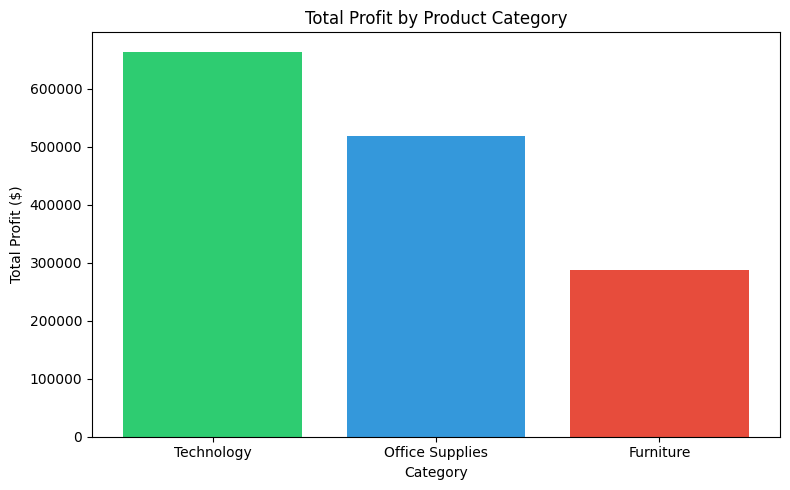

In [42]:
import matplotlib.pyplot as plt

query = """
SELECT p.category, 
       ROUND(SUM(f.profit), 2) AS total_profit
FROM fact_orders f
JOIN dim_products p ON f.product_id = p.product_id
GROUP BY p.category
ORDER BY total_profit DESC
"""

df_category = pd.read_sql(query, connection)

plt.figure(figsize=(8, 5))
plt.bar(df_category['category'], df_category['total_profit'], color=['#2ecc71', '#3498db', '#e74c3c'])
plt.title('Total Profit by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Profit ($)')
plt.tight_layout()
plt.show()